## T1 - Geolocalização e Mapas Digitais

# Integrantes:
- Igor Improta Martinez da Silva | RA: 21.00834-5
- Lucas Gozze Crapino | RA: 22.00667-2
- Murillo Penha Strina | RA: 22.00730-0

Parte 1: Instalando dependências e extraindo base de dados

In [1]:
!pip install osmnx

In [41]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import osmnx as ox
import folium
from folium.plugins import MarkerCluster
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

In [5]:
file_src = 'Ubereat_US_Merchant.csv'
df = pd.read_csv(file_src)

print(f'Total de registros no dataset: {len(df)}')
display(df.head())

Total de registros no dataset: 1000


,index,city,state,zipcode,address,loc_name,loc_number,url,promotion,latitude,...,review_count,review_rating,price_bucket,img1,img2,img3,img4,img5,scan_date,TID
0,0,Alexander City,AL,35010,"4097 U S Highway 280, Alexander City, AL 35010",The Saucy Hen (4097 U. S. HIGHWAY 280),0623b7ac-598d-5016-bdd2-febb44d79b12,https://www.ubereats.com/store/the-saucy-hen-4...,NaN,32.923880,...,NaN,NaN,$$,https://tb-static.uber.com/prod/image-proc/pro...,https://tb-static.uber.com/prod/image-proc/pro...,https://tb-static.uber.com/prod/image-proc/pro...,https://tb-static.uber.com/prod/image-proc/pro...,https://tb-static.uber.com/prod/image-proc/pro...,2022-11-09 18:03:43,1
1,1,Albertville,AL,35951,"7300 Hwy 431 North, Albertville, AL 35951",Burger King (7300 Hwy 431 North),62a60773-5644-4d73-b969-a4922ce70fa6,https://www.ubereats.com/store/burger-king-730...,NaN,34.277260,...,NaN,NaN,$,https://d1ralsognjng37.cloudfront.net/028932d2...,https://d1ralsognjng37.cloudfront.net/86583cc1...,https://d1ralsognjng37.cloudfront.net/0601a57e...,https://d1ralsognjng37.cloudfront.net/b745dbc7...,https://d1ralsognjng37.cloudfront.net/33efde32...,2022-11-09 18:03:43,2
2,2,Alexander City,AL,35010,"4097 Us Highway 280, Alexander City, AL 35010",MrBeast Burger (4097 US Highway 280),308b1654-60f1-51d4-bfe2-ed7c849442ac,https://www.ubereats.com/store/mrbeast-burger-...,NaN,32.923880,...,NaN,NaN,$$,https://d1ralsognjng37.cloudfront.net/a22dc334...,https://d1ralsognjng37.cloudfront.net/3f86d609...,https://d1ralsognjng37.cloudfront.net/e0829c89...,https://d1ralsognjng37.cloudfront.net/0e41e2d9...,https://d1ralsognjng37.cloudfront.net/6284a890...,2022-11-09 18:03:43,3
3,3,Albertville,AL,35950,"7959 Us Hwy 431, Albertville, AL 35950",Taco Bell (7959 Us Highway 431),ef86513f-3973-4315-b938-bb6f230c5c58,https://www.ubereats.com/store/taco-bell-7959-...,"Spend $15, Save $5",34.280000,...,NaN,NaN,$,https://d1ralsognjng37.cloudfront.net/1c1b3198...,https://d1ralsognjng37.cloudfront.net/c8f6f1ea...,https://d1ralsognjng37.cloudfront.net/e669e864...,https://d1ralsognjng37.cloudfront.net/e4053d9a...,https://d1ralsognjng37.cloudfront.net/30fe7bae...,2022-11-09 18:03:43,4
4,4,Alexander City,AL,35010,"977 Jefferson St, Alexander City, AL 35010",The Station,9507eb1b-5afc-4ee1-a566-526d9e2ba2d0,https://www.ubereats.com/store/the-station/950...,NaN,32.956127,...,NaN,NaN,$,https://d1ralsognjng37.cloudfront.net/3b0a4d53...,https://d1ralsognjng37.cloudfront.net/bb83adfa...,https://d1ralsognjng37.cloudfront.net/2156d6be...,https://d1ralsognjng37.cloudfront.net/aa8f2ad2...,https://d1ralsognjng37.cloudfront.net/8a90ff8a...,2022-11-09 18:03:43,5


Parte 2: Extraindo o polígono da cidade com mais pedidos com OSMnx

In [19]:
# 1. Verifica quais estados realmente existem no dataset
print("Alguns estados presentes no dataset:")
print(df['state'])

# 2. Mostra as 5 cidades que têm MAIS restaurantes nesse arquivo
print("\nCidades com mais restaurantes:")
print(df['city'].value_counts().head())

Alguns estados presentes no dataset:
0        AL
1        AL
2        AL
3        AL
4        AL
       ... 
995      AL
996    3321
997      AL
998      AL
999      AL
Name: state, Length: 1000, dtype: object

Cidades com mais restaurantes:
city
Birmingham    376
Hoover         80
Dothan         69
Alabaster      41
Bessemer       39
Name: count, dtype: int64


In [17]:
city_on_focus = 'Birmingham, Alabama, USA'
place_polygon = ox.geocode_to_gdf(city_on_focus)
city_polygon = place_polygon.geometry.iloc[0]

print(f'Polígono da cidade de {city_on_focus}:')
display(place_polygon)

Polígono da cidade de Birmingham, Alabama, USA:


,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"MULTIPOLYGON (((-86.60868 33.56163, -86.60928 ...",-87.122645,33.384212,-86.578312,33.678591,315421088,relation,111031,33.520682,-86.802433,boundary,administrative,16,0.650185,city,Birmingham,"Birmingham, Jefferson County, Alabama, United ..."


Parte 3: Tratamento e Filtro Espacial com Shapely

In [20]:
df_ny = df[df['state'] == 'AL'].copy()

df_ny = df_ny.dropna(subset=['latitude', 'longitude'])

df_ny['geometry'] = df_ny.apply(lambda row: Point((row['longitude'], row['latitude'])), axis=1)

gdf_ny = gpd.GeoDataFrame(df_ny, geometry='geometry', crs="EPSG:4326")

gdf_on_focus = gdf_ny[gdf_ny.geometry.within(city_polygon)].copy()

print(f'Total de registros na cidade de {city_on_focus}: {len(gdf_on_focus)}')

Total de registros na cidade de Birmingham, Alabama, USA: 268


Parte 4: Geração de Mapa estático com Matplotlib e Geopandas


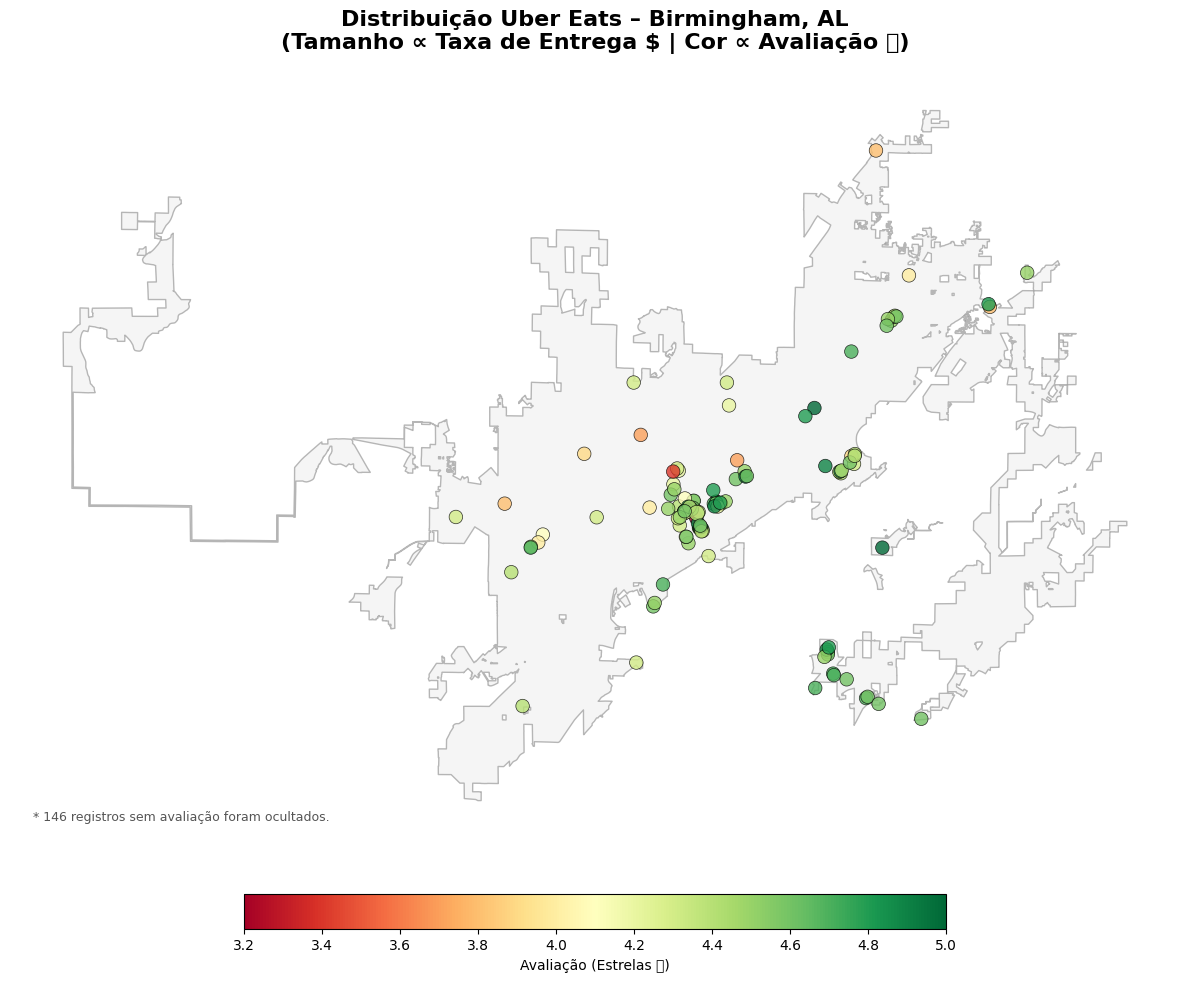

In [42]:
gdf_plot = gdf_on_focus.copy()

gdf_plot['delivery_fee'] = pd.to_numeric(gdf_plot['delivery_fee'], errors='coerce')
mediana_taxa = gdf_plot['delivery_fee'].median()
gdf_plot['fee_to_plot'] = gdf_plot['delivery_fee'].fillna(mediana_taxa)

gdf_plot['review_rating'] = pd.to_numeric(gdf_plot['review_rating'], errors='coerce')
gdf_plot = gdf_plot.dropna(subset=['review_rating'])

sizes = (gdf_plot['fee_to_plot'] * 20) + 15

fig, ax = plt.subplots(figsize=(12, 12))

place_polygon.plot(
    ax=ax,
    color="#f2f2f2", # Cinza muito claro de fundo
    edgecolor="#999999", # Cinza médio para a borda
    linewidth=1.0,
    alpha=0.7,
    label='Limite Municipal'
)

scatter = gdf_plot.plot(
    ax=ax,
    column='review_rating',
    cmap='RdYlGn',
    markersize=sizes,
    alpha=0.8,
    marker='o',
    edgecolor='black',
    linewidth=0.5,
    legend=True,
    legend_kwds={'label': "Avaliação (Estrelas ⭐)", 'orientation': "horizontal", 'shrink': 0.6, 'pad': 0.05}
)

minx, miny, maxx, maxy = city_polygon.bounds
dx = (maxx - minx) * 0.05
dy = (maxy - miny) * 0.05
ax.set_xlim(minx - dx, maxx + dx)
ax.set_ylim(miny - dy, maxy + dy)

plt.title(
    f"Distribuição Uber Eats – Birmingham, AL\n(Tamanho ∝ Taxa de Entrega $ | Cor ∝ Avaliação ⭐)",
    fontsize=16,
    fontweight='bold',
    pad=20
)

n_removidos = len(gdf_on_focus) - len(gdf_plot)
if n_removidos > 0:
    ax.annotate(
        f'* {n_removidos} registros sem avaliação foram ocultados.',
        xy=(0.02, 0.02), xycoords='axes fraction', fontsize=9, color='#555555'
    )

ax.axis('off')

plt.tight_layout()
plt.show()

Parte 4: Mapa interativo utilizando Leaflet / Folium

In [43]:
center_lat = city_polygon.centroid.y
center_lon = city_polygon.centroid.x

folium_map = folium.Map(location=[center_lat, center_lon], zoom_start=12)

cluster = MarkerCluster().add_to(folium_map)

legenda_preco = {
    '$': 'Barato ($)',
    '$$': 'Moderado ($$)',
    '$$$': 'Caro ($$$)',
    '$$$$': 'Muito Caro ($$$$)'
}

for idx, row in gdf_on_focus.iterrows():

    preco_bruto = str(row['price_bucket']).strip()
    if preco_bruto.lower() == 'nan' or preco_bruto == '':
        preco_val = "Não informado"
    else:
        preco_val = legenda_preco.get(preco_bruto, preco_bruto)

    aval_val = str(row['review_rating'])
    if aval_val.lower() == 'nan':
        aval_val = "Sem avaliação"
    else:
        aval_val = f"{aval_val} / 5.0"

    taxa_val = str(row['delivery_fee'])
    if taxa_val.lower() == 'nan':
        taxa_val = "Não informada"
    else:
        taxa_val = f"${taxa_val}"

    info = f"""
    <b>{row['loc_name']}</b><br>
    Preço: {preco_val}<br>
    Avaliação: {aval_val}<br>
    Taxa de Entrega: {taxa_val}
    """

    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=folium.Popup(info, max_width=300),
        icon=folium.Icon(color="darkblue", icon="info-sign")
    ).add_to(cluster)

folium_map